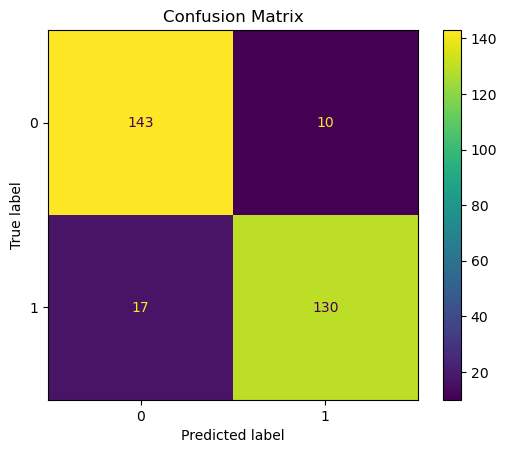

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Data
X, y = make_classification(n_samples=1000, n_features=2,
                           n_redundant=0, n_clusters_per_class=1,
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Model
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

$$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$

In [2]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.91

$$Precision=\frac{TP}{TP+FP}$$

In [3]:
from sklearn.metrics import precision_score
precision_score(y_test, y_pred)

0.9285714285714286

$$Recall=\frac{TP}{TP+FN}$$

In [4]:
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)

0.8843537414965986

$$F_1 \,\,Score = 2 \frac{Preision * Recall}{Precision+Recall}$$

In [5]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.9059233449477352

**Class Imbalance**

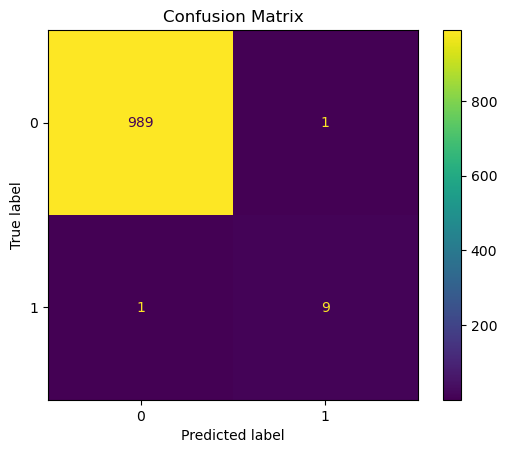

In [8]:
X0 = np.random.randn(990, 2)
X1 = np.random.randn(10, 2) + 2

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(990), np.ones(10)])

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [9]:
print(f"Acc={accuracy_score(y, y_pred)}")
print(f"Prec={precision_score(y, y_pred)}")
print(f"Recall={recall_score(y, y_pred)}")
print(f"F_1={f1_score(y, y_pred)}")

Acc=0.998
Prec=0.9
Recall=0.9
F_1=0.9


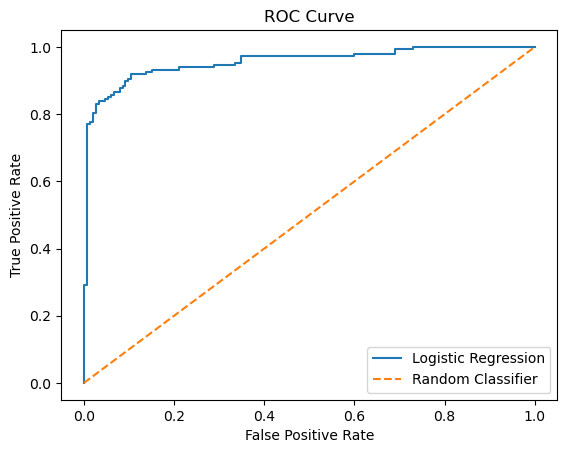

In [10]:
from sklearn.metrics import roc_curve

# Data
X, y = make_classification(n_samples=1000, n_features=2,
                           n_redundant=0, n_clusters_per_class=1,
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Model
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

y_scores = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_scores)

0.9558143669985776

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       152
           1       0.93      0.86      0.90       148

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

